# **MLIS Practical 02**

**Name:** Yesha Pandya  
**Enrollment No:** 23BT04175  
**Division:** A
**Batch**: C

## **Objective:**

Implement a Machine Learning model (Linear Regression) to predict house prices based on input attributes.

## **Step 1: Import Libraries and Load Dataset**
We will use the California Housing dataset. This dataset comes pre-built into `sklearn`

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Fetch the built-in California housing dataset
housing = fetch_california_housing(as_frame=True)
df_b = housing.frame

# Display the first 5 rows
print("Dataset Head:")
display(df_b.head())

Dataset Head:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## **Step 2: Pre-processing**
### **2.1. Removing Outliers**

The original dataset artificially capped all expensive houses at exactly `5.0`. This solid vertical wall of data points confuses a linear model.

We will drop these artificially capped rows so the model learns the true linear trend of the data. Because we are dropping rows, we must create `X_b` and `y_b` directly from `df_b` instead of `housing.data`.

In [ ]:
# Remove artificially capped prices
# Drop rows where the median house value is exactly 5.0
df_b = df_b[df_b['MedHouseVal'] < 5.0]

# Split into Features (X) and Target (y)
# Pulling X and y from the cleaned df_b, not the raw housing object +++
X_b = df_b.drop(columns=['MedHouseVal'])
y_b = df_b['MedHouseVal']

# Split into Training and Testing sets (80% Train, 20% Test)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_b, y_b, test_size=0.2, random_state=42)

### **2.2. Pre-processing (Feature Scaling)**

Features in this dataset have vastly different ranges (e.g., population is in the thousands, while median income is a single digit).

`StandardScaler` normalizes these features so that large numbers don't unfairly dominate the Linear Regression math.

In [ ]:
# Feature Scaling
scaler_b = StandardScaler()
X_train_scaled_b = scaler_b.fit_transform(X_train_b)
X_test_scaled_b = scaler_b.transform(X_test_b)

# Print the size of the new scaled sets
print(f"\nTraining set size: {X_train_scaled_b.shape[0]} samples")
print(f"Testing set size: {X_test_scaled_b.shape[0]} samples")


Training set size: 15718 samples
Testing set size: 3930 samples


### **Important ML Note: Why Split Before Scaling?**

We perform the train-test split *before* applying `StandardScaler` to avoid data leakage.

*   **The Trap (Scaling First):** If we scale the entire dataset together, the scaler uses information from the **test set** (like its maximums, minimums, and averages) to compute the overall scaling parameters. This means the training data gets subtly influenced by the test data before the model even runs.
*   **The Correct Way (Splitting First):** By splitting first, the scaler learns the scaling parameters (mean and standard deviation) *exclusively* from the training data using `.fit_transform()`. It then applies those exact same parameters to the test data using `.transform()`.

This keeps the test set 100% pure and unseen, ensuring our final evaluation metrics are honest and reliable for submission!

## **Step 3: Model Training + Evaluation**
Train the Linear Regression model on the housing features and evaluate its performance.

We'll use Mean Squared Error ($MSE$) and the $R^2$ (coefficient of determination) score.

In [ ]:
# Initialize and train the Linear Regression model
model_b = LinearRegression()

# Train on scaled data
model_b.fit(X_train_scaled_b, y_train_b)

# Make predictions on the test set
# Predict on scaled data
y_pred_b = model_b.predict(X_test_scaled_b)

# Calculate continuous evaluation metrics
mse = mean_squared_error(y_test_b, y_pred_b)
r2 = r2_score(y_test_b, y_pred_b)

print("House Price Prediction Model Performance Metrics: ")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2) Score:     {r2:.4f}")

House Price Prediction Model Performance Metrics: 
Mean Squared Error (MSE): 0.4133
R-squared (R2) Score:     0.5689


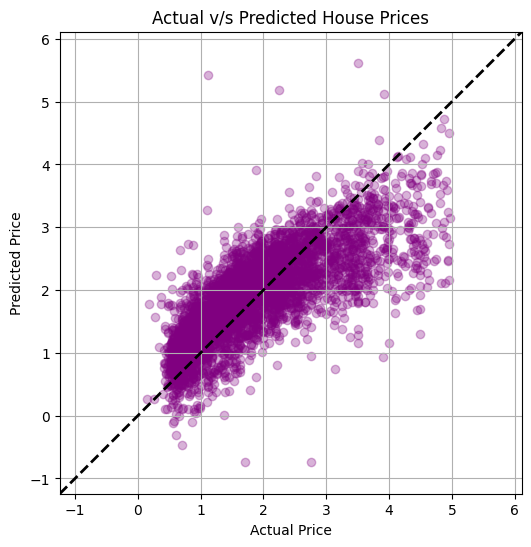

In [ ]:
# Plot Actual v/s Predicted Prices graph
plt.figure(figsize=(6, 6))
plt.scatter(y_test_b, y_pred_b, alpha=0.3, color='purple')

# Find the absolute min and max limits for our axes
min_val = min(y_test_b.min(), y_pred_b.min()) - 0.5
max_val = max(y_test_b.max(), y_pred_b.max()) + 0.5

# Draw the perfect prediction dashed line using new limits
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)

# Force the X and Y axes to have the exact same scale
plt.xlim([min_val, max_val])
plt.ylim([min_val, max_val])

# Force the physical plot to render as a perfect square (for better visualization hehe)
plt.gca().set_aspect('equal', adjustable='box')

plt.title('Actual v/s Predicted House Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.grid(True)
plt.show()